In [1]:
!pip install datasets==2.19.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [8]:
import pandas as pd
import numpy as np
from google.colab import files

print("Đang tiến hành gán nhãn thông minh cho toàn bộ dữ liệu...")

# 1. Đọc file dữ liệu chính
df_final = pd.read_csv('vietnamese_education_feedback_completed.csv')

# 2. GÁN NHÃN CHO 16.175 DÒNG TỪ UIT (sử dụng ánh xạ cố định từ dữ liệu gốc)
# Dataset UIT gồm train (11.426) + validation (1.583) + test (3.166) = 16.175 dòng
NUM_UIT = 16175

# Nhãn cảm xúc UIT: 0=Tiêu cực, 1=Trung tính, 2=Tích cực
sentiment_map = {0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'}

# Nhãn chủ đề UIT: 0=Giảng viên, 1=Chương trình đào tạo, 2=Cơ sở vật chất, 3=Khác, 4=Khác
topic_map = {0: 'Giảng viên', 1: 'Chương trình đào tạo', 2: 'Cơ sở vật chất', 3: 'Khác', 4: 'Khác'}

# Tải dataset UIT để lấy nhãn gốc (đảm bảo thứ tự đúng)
from datasets import load_dataset
dataset_uit = load_dataset("uitnlp/vietnamese_students_feedback", trust_remote_code=True)

# Ghép theo đúng thứ tự: train -> validation -> test
df_uit = pd.concat([
    dataset_uit['train'].to_pandas(),
    dataset_uit['validation'].to_pandas(),
    dataset_uit['test'].to_pandas()
], ignore_index=True)

# Kiểm tra số dòng UIT khớp với hằng số đã định
assert len(df_uit) == NUM_UIT, f"Số dòng UIT thực tế ({len(df_uit)}) không khớp với NUM_UIT ({NUM_UIT})"

# Ánh xạ nhãn số sang chữ
uit_sentiments = df_uit['sentiment'].map(sentiment_map).values
uit_topics    = df_uit['topic'].map(topic_map).values

# 3. XÂY DỰNG LUẬT TỪ KHÓA (LEXICON-BASED) CHO PHẦN APP REVIEWS
pos_words = ['tốt', 'hay', 'tuyệt', 'đỉnh', 'ok', 'oke', 'hiệu quả', 'hữu ích',
             'cảm ơn', 'nhanh', 'mượt', 'dễ hiểu', 'chính xác', '10 điểm', 'ổn']
neg_words = ['tệ', 'chán', 'lag', 'lỗi', 'chậm', 'kém', 'sai', 'đắt',
             'quảng cáo', 'thất vọng', 'không', 'khó', 'xoá', 'phiền']

def auto_label_sentiment(text):
    text = str(text).lower()
    pos_score = sum(1 for w in pos_words if w in text)
    neg_score = sum(1 for w in neg_words if w in text)
    if pos_score > neg_score:   return 'Tích cực'
    elif neg_score > pos_score: return 'Tiêu cực'
    else:                       return 'Trung tính'

def auto_label_topic(text):
    text = str(text).lower()
    if any(w in text for w in ['lag', 'lỗi', 'vào', 'màn hình', 'quảng cáo',
                                'chậm', 'mượt', 'app', 'giao diện']):
        return 'Trải nghiệm ứng dụng'
    elif any(w in text for w in ['từ vựng', 'ngữ pháp', 'giải', 'đáp án',
                                  'bài tập', 'học', 'câu hỏi', 'đúng']):
        return 'Chất lượng học tập'
    else:
        return 'Khác'

# 4. TIẾN HÀNH GÁN NHÃN VÀO DATAFRAME
df_final['sentiment'] = np.nan
df_final['topic']     = np.nan

# Gán nhãn cho 16.175 dòng UIT (dùng .values để tránh lệch index)
df_final.loc[:NUM_UIT - 1, 'sentiment'] = uit_sentiments
df_final.loc[:NUM_UIT - 1, 'topic']     = uit_topics

# Gán nhãn tự động cho phần App Reviews còn lại
df_final.loc[NUM_UIT:, 'sentiment'] = (
    df_final.loc[NUM_UIT:, 'sentence'].apply(auto_label_sentiment)
)
df_final.loc[NUM_UIT:, 'topic'] = (
    df_final.loc[NUM_UIT:, 'sentence'].apply(auto_label_topic)
)

# 5. KIỂM TRA VÀ LƯU KẾT QUẢ
print("" + "="*50)
print("DỮ LIỆU ĐÃ ĐƯỢC GÁN NHÃN THÀNH CÔNG!")
print("="*50)
print(f"Tổng số dòng: {len(df_final)}")
print(f"  - Dòng UIT (0 – {NUM_UIT-1}): {NUM_UIT} dòng")
print(f"  - Dòng App Reviews ({NUM_UIT} – {len(df_final)-1}): {len(df_final)-NUM_UIT} dòng")
print("Phân bổ sentiment:")
print(df_final['sentiment'].value_counts())
print("Phân bổ topic:")
print(df_final['topic'].value_counts())
print("Mẫu ngẫu nhiên 5 dòng:")
print(df_final[['feedback_id', 'sentence', 'sentiment', 'topic']].sample(5))

final_labeled_name = 'vietnamese_education_feedback_labeled.csv'
df_final.to_csv(final_labeled_name, index=False, encoding='utf-8-sig')
print(f"Đã lưu thành file {final_labeled_name}. Đang tải về máy...")
files.download(final_labeled_name)


Đang tiến hành gán nhãn thông minh cho toàn bộ dữ liệu...


Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

/tmp/ipykernel_6372/2582646359.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Tích cực' 'Tích cực' 'Tiêu cực' ... 'Tích cực' 'Tiêu cực' 'Trung tính']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_final.loc[:NUM_UIT - 1, 'sentiment'] = uit_sentiments
/tmp/ipykernel_6372/2582646359.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Chương trình đào tạo' 'Giảng viên' 'Chương trình đào tạo' ...
 'Giảng viên' 'Giảng viên' 'Chương trình đào tạo']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_final.loc[:NUM_UIT - 1, 'topic']     = uit_topics


DỮ LIỆU ĐÃ ĐƯỢC GÁN NHÃN THÀNH CÔNG!
Tổng số dòng: 40675
  - Dòng UIT (0 – 16174): 16175 dòng
  - Dòng App Reviews (16175 – 40674): 24500 dòng
Phân bổ sentiment:
sentiment
Tích cực      17721
Tiêu cực      11852
Trung tính    11102
Name: count, dtype: int64
Phân bổ topic:
topic
Khác                    12422
Giảng viên              11607
Trải nghiệm ứng dụng     6573
Chất lượng học tập       6321
Chương trình đào tạo     3040
Cơ sở vật chất            712
Name: count, dtype: int64
Mẫu ngẫu nhiên 5 dòng:
      feedback_id                                           sentence  \
1163     FB_01164  ghi quá nhiều , giảng dạy còn khó hiểu , nên s...   
581      FB_00582    cô rất nhiệt tình và thân thiện với sinh viên .   
10155    FB_10156     nên chú trọng vào môn học là hướng đối tượng .   
19195    FB_19196                              rất oki, lên dùng thử   
31177    FB_31178                                        App như cac   

        sentiment                 topic  
1163     Tiêu cực

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

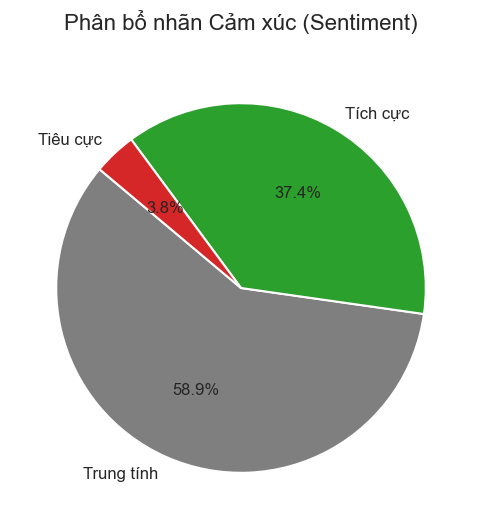

/tmp/ipykernel_6372/1181346831.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Blues_r')


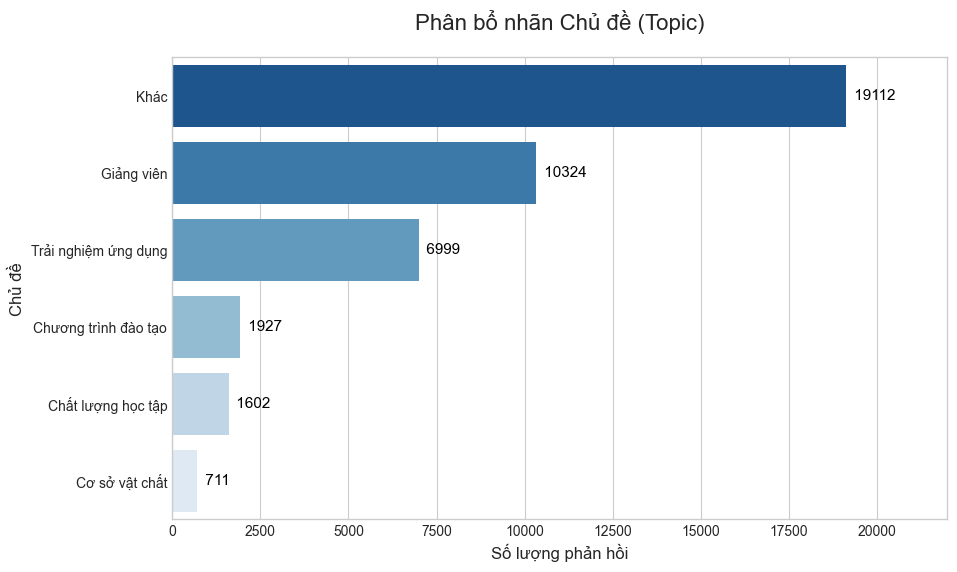

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import urllib.request
import os

# =========================================================================
# VÁ LỖI FONT TIẾNG VIỆT CHO MATPLOTLIB (Chạy tốt trên cả Colab và máy tính)
# =========================================================================
font_path = 'Arial.ttf'
# Tải font Arial nếu chưa có trong thư mục
if not os.path.exists(font_path):
    urllib.request.urlretrieve("https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf", font_path)

# Đăng ký font với Matplotlib và thiết lập làm font mặc định
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Arial'
# =========================================================================

# Thiết lập style để biểu đồ trông hiện đại, chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid')

# Đọc dữ liệu
df = pd.read_csv('vietnamese_education_feedback_labeled.csv')

# ==========================================
# 1. VẼ BIỂU ĐỒ TRÒN CHO NHÃN CẢM XÚC (SENTIMENT)
# ==========================================
sentiment_counts = df['sentiment'].value_counts()

# Đặt màu sắc chuẩn: Tích cực (Xanh lá), Tiêu cực (Đỏ), Trung tính (Xám)
color_map = {'Tích cực': '#2ca02c', 'Tiêu cực': '#d62728', 'Trung tính': '#7f7f7f'}
colors = [color_map.get(x, '#333333') for x in sentiment_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Phân bổ nhãn Cảm xúc (Sentiment)', fontsize=16, fontweight='bold', pad=20)
plt.savefig('sentiment_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# ==========================================
# 2. VẼ BIỂU ĐỒ CỘT NGANG CHO NHÃN CHỦ ĐỀ (TOPIC)
# ==========================================
topic_counts = df['topic'].value_counts()

plt.figure(figsize=(10, 6))
# Sử dụng barplot ngang vì tên các chủ đề khá dài
ax = sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Blues_r')

plt.title('Phân bổ nhãn Chủ đề (Topic)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng phản hồi', fontsize=12)
plt.ylabel('Chủ đề', fontsize=12)

# Thêm số lượng cụ thể hiển thị ở đuôi mỗi cột
for i, v in enumerate(topic_counts.values):
    ax.text(v + 100, i, f" {v}", color='black', va='center', fontsize=11)

# Mở rộng trục X một chút để số lượng không bị lẹm ra ngoài
plt.xlim(0, max(topic_counts.values) * 1.15)
plt.savefig('topic_distribution.png', bbox_inches='tight', dpi=300)
plt.show()